# V15 safe-admission verification with a heuristic upper agent

This notebook mimics the new upper agent with a deterministic load-based bias rule. It compares the same directional A3 decisions with safe admission enabled and disabled.

The controlled eMBB snapshot starts at loads `[0.90, 0.40, 0.50]`. Ten source UEs are radio-eligible toward both neighbors. The expected safe capacities are two UEs toward gNB1 and one UE toward gNB2; the unsafe baseline is allowed to migrate every eligible UE.

In [1]:
import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/mpl')
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from global_ppo_3gnb_env import DEFAULT_GNB_CONFIGS_3, SLICE_TYPES
from scenario_creator import create_multignb_env
from strong_heuristic_local_executor import strong_directional_heuristic_local_executor

plt.style.use('seaborn-v0_8-whitegrid')
SLICE_INDEX = {name: idx for idx, name in enumerate(SLICE_TYPES)}
NEIGHBORS = {0: [1, 2], 1: [0, 2], 2: [0, 1]}
SAFE_LIMIT = 0.80
print('Project root:', PROJECT_ROOT)


Project root: /home/oussama/Desktop/chech


## Controlled simulator and heuristic controller

The scheduler is not used to manufacture the result. We seed each UE's PRB contribution directly so the safe layer sees the intended snapshot. The upper heuristic emits `-0.8` above the slice average plus a deadband, `+0.4` below the average minus the deadband, and zero otherwise.

In [2]:
def force_attach(env, ue_id, gnb_id):
    ue = env.get_ue(ue_id)
    for gnb in env.gnbs:
        gnb.detach_ue(ue_id)
    target = env._get_gnb_by_id(gnb_id)
    assert target.attach_ue(ue)
    ue.serving_gnb = int(gnb_id)
    ue.connected = True
    env._last_serving_gnb[ue_id] = int(gnb_id)


def build_controlled_env(safe_enabled):
    rng = np.random.default_rng(15)
    env = create_multignb_env(
        rng=rng,
        n=4,
        gnb_configs=DEFAULT_GNB_CONFIGS_3,
        slots_per_step=1,
        L1_level=False,
        step_dt=1e-3,
        mobility_dt=0.0,
        radio_substeps=1,
        max_episode_steps=10,
        handover_ttt=1,
        safe_admission_enabled=safe_enabled,
        safe_admission_load_limits={s: SAFE_LIMIT for s in SLICE_TYPES},
    )
    env.clear_ues(reset_ids=True)

    # (gNB, UE count, PRBs per UE) -> exact loads 0.90, 0.40, 0.50.
    for gnb_id, count, prbs in ((0, 10, 9), (1, 4, 10), (2, 5, 10)):
        gnb = env._get_gnb_by_id(gnb_id)
        for idx in range(count):
            ue_id = env.add_ue(
                x=float(gnb.x + 5 + idx),
                y=float(gnb.y),
                slice_type='eMBB',
            )
            force_attach(env, ue_id, gnb_id)
            ue = env.get_ue(ue_id)
            ue.prbs = prbs
            ue.useful_prbs = prbs
            ue.wasted_prbs = 0

    # Controlled radio ordering: for gNB0 UEs, gNB1 is strongest and gNB2
    # is the second eligible target. This tests per-direction capacities.
    def controlled_rsrp(gnb, ue):
        serving = int(ue.serving_gnb)
        target = int(gnb.id)
        if target == serving:
            return -80.0
        if serving == 0 and target == 1:
            return -70.0
        if serving == 0 and target == 2:
            return -72.0
        return -100.0

    env._measure_rsrp = controlled_rsrp
    env._invalidate_metric_caches()
    return env


def load_matrix(env):
    loads = env.get_slice_loads()
    return np.asarray([
        [loads.get((g, s), 0.0) for s in SLICE_TYPES]
        for g in range(3)
    ], dtype=float)


def heuristic_upper_bias(loads, deadband=0.05):
    means = loads.mean(axis=0, keepdims=True)
    bias = np.zeros_like(loads)
    bias[loads > means + deadband] = -0.8
    bias[loads < means - deadband] = +0.4
    return bias


def directional_offsets(env, bias, previous=None):
    ues = [ue for ue in env.get_all_ues() if ue.connected]
    ue_slice = np.asarray([SLICE_INDEX[ue.slice_type] for ue in ues], dtype=int)
    serving = np.asarray([ue.serving_gnb for ue in ues], dtype=int)
    rsrp = np.asarray([
        [env._measure_rsrp(env._get_gnb_by_id(g), ue) for g in range(3)]
        for ue in ues
    ], dtype=float)
    if previous is None:
        previous = np.zeros((3, 2, 3), dtype=float)
    zeros = np.zeros((3, 2, 3), dtype=float)
    return strong_directional_heuristic_local_executor(
        B=bias,
        prev_offsets=previous,
        ue_slice=ue_slice,
        ue_serving_gnb=serving,
        rsrp_matrix=rsrp,
        neighbor_graph=NEIGHBORS,
        load=load_matrix(env),
        sla_violation=np.zeros((3, 3), dtype=float),
        ho_failure_ratio=zeros,
        pingpong_ratio=zeros,
        hysteresis_db=env.a3_hysteresis_db,
        l_safe=SAFE_LIMIT,
        allow_extended_negative_offsets=True,
    )


def apply_offsets(env, offsets):
    for source, neighbors in NEIGHBORS.items():
        for slot, target in enumerate(neighbors):
            for s_idx, slice_type in enumerate(SLICE_TYPES):
                env.set_a3_offset(source, target, slice_type, offsets[source, slot, s_idx])


In [3]:
def run_case(safe_enabled):
    env = build_controlled_env(safe_enabled)
    before = load_matrix(env)
    bias = heuristic_upper_bias(before)
    offsets = directional_offsets(env, bias)
    apply_offsets(env, offsets)
    capacities = env.begin_safe_admission_window(bias, SLICE_TYPES)
    handovers = env._evaluate_a3_handovers()
    after = load_matrix(env)
    state = env.get_safe_admission_state()
    events = pd.DataFrame(env.get_handover_events())
    result = {
        'safe_enabled': safe_enabled,
        'before': before,
        'after': after,
        'bias': bias,
        'offsets': offsets,
        'capacities': capacities,
        'admission': state,
        'handovers': handovers,
        'events': events,
    }
    env.close()
    return result


safe = run_case(True)
unsafe = run_case(False)

summary = pd.DataFrame([
    {
        'case': 'safe admission',
        'handovers': safe['handovers'],
        'max final eMBB load': safe['after'][:, 0].max(),
        'final eMBB variance': safe['after'][:, 0].var(),
        'hard-limit violations': int(np.sum(safe['after'][:, 0] > SAFE_LIMIT)),
    },
    {
        'case': 'unsafe baseline',
        'handovers': unsafe['handovers'],
        'max final eMBB load': unsafe['after'][:, 0].max(),
        'final eMBB variance': unsafe['after'][:, 0].var(),
        'hard-limit violations': int(np.sum(unsafe['after'][:, 0] > SAFE_LIMIT)),
    },
])
summary


,case,handovers,max final eMBB load,final eMBB variance,hard-limit violations
0,safe admission,3,0.63,0.000467,0
1,unsafe baseline,10,1.00,0.166667,1


## Controller decisions

The upper bias is non-directional. Directionality appears only in the local offsets. The admission plot then shows how the bias magnitude is converted into a per-target migration budget.

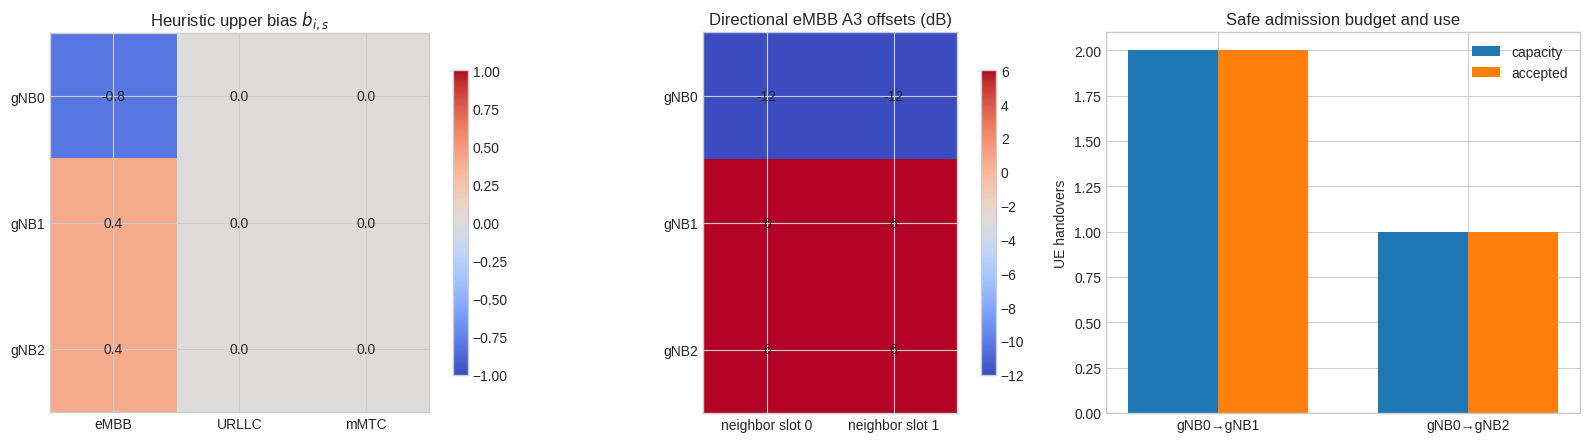

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

im = axes[0].imshow(safe['bias'], vmin=-1, vmax=1, cmap='coolwarm')
axes[0].set_title('Heuristic upper bias $b_{i,s}$')
axes[0].set_xticks(range(3), SLICE_TYPES)
axes[0].set_yticks(range(3), [f'gNB{i}' for i in range(3)])
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f'{safe["bias"][i,j]:.1f}', ha='center', va='center')
fig.colorbar(im, ax=axes[0], shrink=0.8)

embb_offsets = safe['offsets'][:, :, 0]
im2 = axes[1].imshow(embb_offsets, vmin=-12, vmax=6, cmap='coolwarm')
axes[1].set_title('Directional eMBB A3 offsets (dB)')
axes[1].set_xticks([0, 1], ['neighbor slot 0', 'neighbor slot 1'])
axes[1].set_yticks(range(3), [f'gNB{i}' for i in range(3)])
for i in range(3):
    for j in range(2):
        axes[1].text(j, i, f'{embb_offsets[i,j]:.0f}', ha='center', va='center')
fig.colorbar(im2, ax=axes[1], shrink=0.8)

directions = [(0, 1, 'EMBB'), (0, 2, 'EMBB')]
labels = ['gNB0→gNB1', 'gNB0→gNB2']
capacity = [safe['capacities'][key] for key in directions]
accepted = [safe['admission']['accepted'][key] for key in directions]
x = np.arange(len(labels))
axes[2].bar(x - 0.18, capacity, 0.36, label='capacity')
axes[2].bar(x + 0.18, accepted, 0.36, label='accepted')
axes[2].set_xticks(x, labels)
axes[2].set_ylabel('UE handovers')
axes[2].set_title('Safe admission budget and use')
axes[2].legend()

plt.tight_layout()
plt.show()


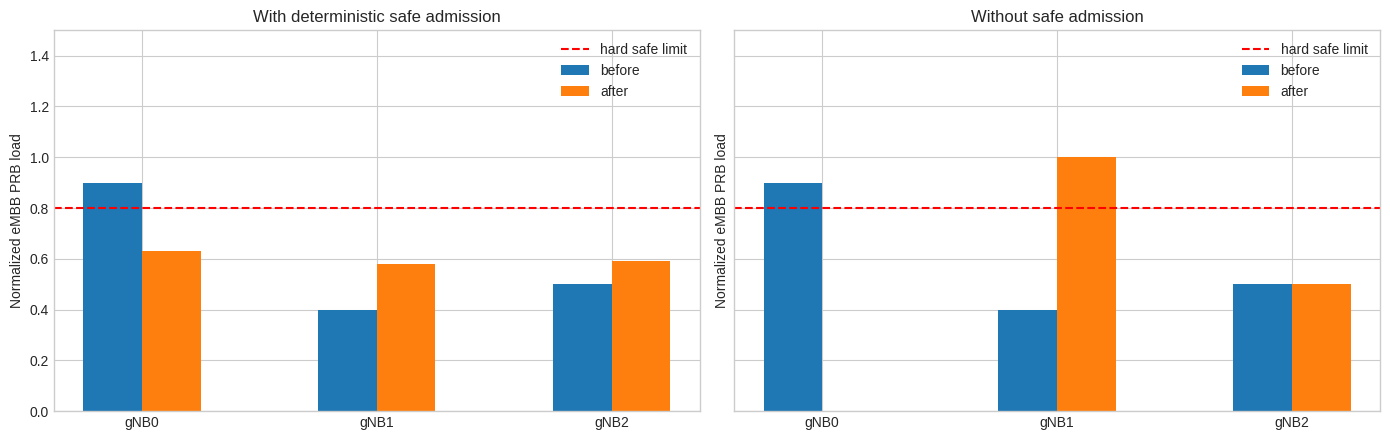

,count
safe-layer outcome,
eligible,18
accepted,3
rejected_no_pressure,0
rejected_no_source_excess,0
rejected_no_target_headroom,0
rejected_capacity,15
rejected_target_safety,0


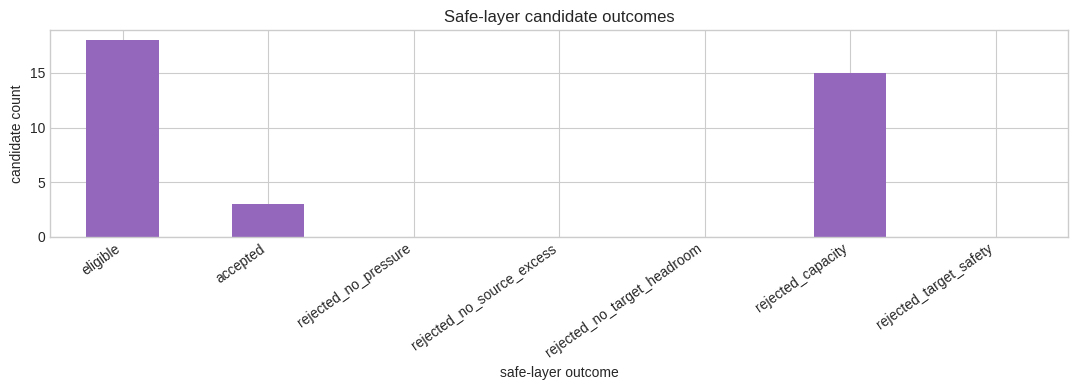

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
x = np.arange(3)
width = 0.25
for ax, result, title in zip(
    axes,
    (safe, unsafe),
    ('With deterministic safe admission', 'Without safe admission'),
):
    ax.bar(x - width/2, result['before'][:, 0], width, label='before')
    ax.bar(x + width/2, result['after'][:, 0], width, label='after')
    ax.axhline(SAFE_LIMIT, color='red', linestyle='--', label='hard safe limit')
    ax.set_xticks(x, [f'gNB{i}' for i in range(3)])
    ax.set_ylim(0, max(1.5, result['after'][:, 0].max() + 0.1))
    ax.set_title(title)
    ax.set_ylabel('Normalized eMBB PRB load')
    ax.legend()

plt.tight_layout()
plt.show()

stats = safe['admission']['stats']
stats_df = pd.DataFrame({'count': stats}).rename_axis('safe-layer outcome')
display(stats_df)

stats_df.plot(kind='bar', figsize=(11, 4), legend=False, color='tab:purple')
plt.ylabel('candidate count')
plt.title('Safe-layer candidate outcomes')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


## Automatic verification

These assertions turn the notebook into a reproducible regression check. They verify the PDF capacity equation, controlled migration, target safety, and the failure mode of the unsafe baseline.

In [6]:
assert np.allclose(safe['before'][:, 0], [0.90, 0.40, 0.50])
assert safe['capacities'][(0, 1, 'EMBB')] == 2
assert safe['capacities'][(0, 2, 'EMBB')] == 1
assert safe['admission']['accepted'][(0, 1, 'EMBB')] <= 2
assert safe['admission']['accepted'][(0, 2, 'EMBB')] <= 1
assert safe['after'][:, 0].max() <= SAFE_LIMIT + 1e-12
assert safe['after'][:, 0].var() < safe['before'][:, 0].var()
assert unsafe['after'][:, 0].max() > SAFE_LIMIT
assert unsafe['handovers'] > safe['handovers']
assert safe['events']['ue_id'].nunique() == safe['handovers']

print('PASS: capacities match the v15 formula.')
print('PASS: safe admission limits migration and keeps every target below the hard limit.')
print('PASS: the unsafe baseline demonstrates total migration / target overload.')
display(summary.round(4))
display(safe['events'][['ue_id', 'from_gnb', 'to_gnb', 'offset_db', 'safe_admission']])


PASS: capacities match the v15 formula.
PASS: safe admission limits migration and keeps every target below the hard limit.
PASS: the unsafe baseline demonstrates total migration / target overload.


,case,handovers,max final eMBB load,final eMBB variance,hard-limit violations
0,safe admission,3,0.63,0.0005,0
1,unsafe baseline,10,1.00,0.1667,1


,ue_id,from_gnb,to_gnb,offset_db,safe_admission
0,0,0,1,-12.0,True
1,1,0,1,-12.0,True
2,2,0,2,-12.0,True
